# WorldCup Analytics Lab - Final Project
### Investigating Post-Peak Performance Decline in FIFA World Cup Tournaments

---

## Research Hypothesis

> *Teams that achieve strong results in one FIFA World Cup show a statistically significant decline in the subsequent tournament, measured by stage reached.*

We investigate this through five analytical questions using a full ML pipeline:

| # | Question | Model |
|---|---|---|
| Q1 | Does stage reached in tournament N negatively predict stage reached in N+1? | Ordinal / Linear Regression |
| Q2 | After controlling for FIFA ranking and squad age, does prior success still predict decline? | Multiple Regression |
| Q3 | Can we predict binary underperformance in N+1 from N metrics? | Binary Classification |
| Q4 | Can we predict exact finishing tier in N+1? | Multiclass Classification |
| Q5 | Do teams group into distinct consecutive-performance profiles? | K-Means Clustering |

---

## Section 0 - Setup & Dependencies

In [1]:
# Install required packages
import subprocess, sys
packages = ['pandas', 'numpy', 'matplotlib', 'seaborn', 'scikit-learn',
            'statsmodels', 'requests', 'kaggle']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])
print('All packages ready.')

All packages ready.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import os
import requests
import io
import zipfile

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, silhouette_score,
                              accuracy_score)
import statsmodels.api as sm
import statsmodels.formula.api as smf

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='Blues_d')
plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})

RANDOM_STATE = 42
FJELSTUL_BASE = "https://raw.githubusercontent.com/jfjelstul/worldcup/master/data-csv"
DATO_BASE = "https://raw.githubusercontent.com/Dato-Futbol/fifa-ranking/master"
print('Imports successful.')

Imports successful.


---
## Section 1 - Data Loading

We use three datasets:
1. **Fjelstul World Cup Database** - match results, standings, squads (GitHub)
2. **martj42 International Football Results** - 49k+ international matches (Kaggle)
3. **Dato-Futbol FIFA Historical Rankings** - FIFA rank & points 1992–2024 (GitHub)

The cell below attempts to fetch all datasets automatically. If fetching fails, a realistic synthetic dataset is generated so the notebook runs end-to-end.

In [3]:
# ─────────────────────────────────────────────────────────────
# DATA LOADING - AUTO FETCH WITH SYNTHETIC FALLBACK
# ─────────────────────────────────────────────────────────────

def fetch_csv(url, label):
    """Try to fetch a CSV from URL; return DataFrame or None."""
    try:
        r = requests.get(url, timeout=15)
        r.raise_for_status()
        df = pd.read_csv(io.StringIO(r.text))
        print(f'  [OK] {label}: {df.shape[0]:,} rows, {df.shape[1]} cols')
        return df
    except Exception as e:
        print(f'  [FAILED] {label}: {e}')
        return None

print('Fetching Fjelstul datasets...')
df_standings   = fetch_csv(f'{FJELSTUL_BASE}/tournament_standings.csv', 'tournament_standings')
df_group       = fetch_csv(f'{FJELSTUL_BASE}/group_standings.csv',      'group_standings')
df_squads      = fetch_csv(f'{FJELSTUL_BASE}/squads.csv',               'squads')
df_teams       = fetch_csv(f'{FJELSTUL_BASE}/team_appearances.csv',     'team_appearances')

print('\nFetching Dato-Futbol FIFA Rankings...')
df_rankings    = fetch_csv(f'{DATO_BASE}/ranking_fifa_historical.csv',  'fifa_rankings')

print('\nFetching martj42 (Kaggle)...')
df_intl = None
try:
    df_intl = pd.read_csv('kaggle_dataset/results.csv')
    print(f'  [OK] International Matches: {df_intl.shape[0]:,} rows, {df_intl.shape[1]} cols')
except Exception as e:
    print(f'  [FAILED] martj42 local file: {e}')
    print('  -> International results will be excluded if no real data is available.')


Fetching Fjelstul datasets...
  [OK] tournament_standings: 120 rows, 7 cols
  [OK] group_standings: 626 rows, 19 cols
  [OK] squads: 13,843 rows, 12 cols
  [OK] team_appearances: 2,496 rows, 36 cols

Fetching Dato-Futbol FIFA Rankings...
  [OK] fifa_rankings: 67,894 rows, 6 cols

Fetching martj42 (Kaggle)...
  [OK] International Matches: 49,287 rows, 9 cols


### Data Loading Summary

All three datasets loaded successfully:
- **Fjelstul** - `tournament_standings` (top 4 per tournament), `group_standings` (all teams), `squads`, `team_appearances`
- **martj42** - 49,287 international match results from 1872–2024 across 9 columns: `date`, `home_team`, `away_team`, `home_score`, `away_score`, `tournament`, `city`, `country`, `neutral`
- **Dato-Futbol** - Historical FIFA rankings 1992–2024

> **Note on `former_names.csv`:** The martj42 dataset includes a `former_names.csv` table mapping historical country names to current names (e.g., *Dahomey -> Benin*, *Upper Volta -> Burkina Faso*). This should be used during the country name standardization step to ensure consistent merging across datasets - especially for teams that competed under former names in earlier tournaments.

In [4]:
# ─────────────────────────────────────────────────────────────
# SYNTHETIC FALLBACK
# Generates realistic data mirroring actual dataset schemas.
# Skipped automatically if real data loaded above.
# ─────────────────────────────────────────────────────────────

USE_SYNTHETIC = df_standings is None

if USE_SYNTHETIC:
    print('Real data unavailable - generating synthetic dataset.\n')
    np.random.seed(RANDOM_STATE)

    WC_YEARS = [1930,1934,1938,1950,1954,1958,1962,1966,1970,1974,
                1978,1982,1986,1990,1994,1998,2002,2006,2010,2014,2018,2022]
    TEAMS = [
        'Brazil','Germany','Argentina','France','Italy','Spain',
        'England','Netherlands','Portugal','Uruguay','Croatia',
        'Belgium','Mexico','USA','South Korea','Japan','Senegal',
        'Cameroon','Nigeria','Australia','Poland','Sweden'
    ]
    STAGES = ['Group Stage','Round of 16','Quarter-final','Semi-final','Final','Winner']
    STAGE_NUM = {s:i+1 for i,s in enumerate(STAGES)}

    # Teams qualify for ~50% of tournaments
    rows = []
    for year in WC_YEARS:
        n_teams = 16 if year < 1982 else 32 if year >= 1998 else 24
        participating = np.random.choice(TEAMS, size=min(n_teams, len(TEAMS)), replace=False)
        for team in participating:
            # Elite teams reach later stages more often
            elite = team in ['Brazil','Germany','Argentina','France','Italy','Spain']
            probs = [0.25,0.25,0.20,0.15,0.10,0.05] if elite else [0.45,0.25,0.15,0.10,0.04,0.01]
            stage = np.random.choice(STAGES, p=probs)
            rows.append({'year': year, 'team_name': team, 'stage_reached': stage,
                         'stage_num': STAGE_NUM[stage],
                         'goals_for': np.random.randint(1,12),
                         'goals_against': np.random.randint(0,10)})

    df_standings = pd.DataFrame(rows)

    # Squads
    squad_rows = []
    for _, row in df_standings.iterrows():
        for i in range(23):
            squad_rows.append({
                'year': row['year'], 'team_name': row['team_name'],
                'player_id': f"{row['team_name']}_{row['year']}_{i}",
                'age': int(np.random.normal(27, 3.5))
            })
    df_squads = pd.DataFrame(squad_rows)
    df_squads['age'] = df_squads['age'].clip(18, 40)

    # International results (martj42 proxy)
    intl_rows = []
    for year in range(1990, 2023):
        for _ in range(200):
            h, a = np.random.choice(TEAMS, 2, replace=False)
            hs = np.random.poisson(1.4)
            as_ = np.random.poisson(1.2)
            intl_rows.append({
                'date': f'{year}-{np.random.randint(1,13):02d}-{np.random.randint(1,28):02d}',
                'home_team': h, 'away_team': a,
                'home_score': hs, 'away_score': as_,
                'tournament': np.random.choice(
                    ['Friendly','FIFA World Cup qualification','UEFA Nations League'], p=[0.5,0.3,0.2])
            })
    df_intl = pd.DataFrame(intl_rows)
    df_intl['date'] = pd.to_datetime(df_intl['date'])

    # FIFA Rankings
    rank_rows = []
    for year in WC_YEARS:
        for i, team in enumerate(TEAMS):
            rank_rows.append({
                'rank_date': f'{year}-03-01',
                'country_full': team,
                'rank': i + 1 + np.random.randint(-3, 4),
                'total_points': max(100, 1800 - i*70 + np.random.randint(-50,50))
            })
    df_rankings = pd.DataFrame(rank_rows)
    df_rankings['rank_date'] = pd.to_datetime(df_rankings['rank_date'])
    df_rankings['rank'] = df_rankings['rank'].clip(1, len(TEAMS))

    print('Synthetic data generated:')
    print(f'  tournament_standings: {df_standings.shape}')
    print(f'  squads:               {df_squads.shape}')
    print(f'  intl results:         {df_intl.shape}')
    print(f'  fifa rankings:        {df_rankings.shape}')
else:
    print('Using real data - synthetic fallback skipped.')

Using real data - synthetic fallback skipped.


---
## Section 2 - Data Cleaning & Feature Engineering

Before modeling, we:
1. Standardize country names across datasets
2. Encode stage reached as an ordinal integer (1–6)
3. Engineer the sliding window - pairing each team's (tournament N, tournament N+1)
4. Compute average squad age and player retention per team per tournament
5. Join FIFA rankings and pre-tournament form

In [ ]:
# ── Stage encoding ──────────────────────────────────────────
# Strategy:
# - tournament_standings has top 4 finishers (positions 1-4) with exact finish
# - group_standings has ALL teams with stage_name and advanced flag
# - We combine both to assign stage_num to every team

# Step 1: From tournament_standings, map top 4
def position_to_stage(position):
    if position == 1: return 6   # Winner
    elif position == 2: return 5  # Final
    else: return 4               # Semi-final (3rd and 4th)

df_standings['stage_num'] = df_standings['position'].apply(position_to_stage)
top4 = df_standings[['tournament_id','team_id','stage_num']].copy()

# Step 2: From group_standings, get all teams and their deepest stage
# stage_name tells us which round they were eliminated in
stage_name_map = {
    'group stage': 1,
    'first round': 1,
    'first group stage': 1,
    'second group stage': 2,
    'final round': 2,
    'round of 16': 2,
    'second round': 2,
    'quarter-finals': 3,
    'quarter-final': 3,
    'semi-finals': 4,
    'semi-final': 4,
    'third-place match': 4,
    'final': 5,
}

df_group['stage_num_raw'] = df_group['stage_name'].str.lower().map(stage_name_map)

# For each team in each tournament, take the MAXIMUM stage they reached
# (they appear in group_standings for each round they participated in)
group_max = (df_group.groupby(['tournament_id','team_id'])['stage_num_raw']
             .max()
             .reset_index()
             .rename(columns={'stage_num_raw':'stage_num'}))

# Step 3: Merge - top4 overrides group_max for finalists
all_stages = group_max.merge(
    top4.rename(columns={'stage_num':'stage_num_top4'}),
    on=['tournament_id','team_id'], how='left')

all_stages['stage_num'] = all_stages['stage_num_top4'].fillna(all_stages['stage_num'])
all_stages['stage_num'] = all_stages['stage_num'].astype(int)

# Step 4: Merge back onto a clean base with team names
team_lookup = df_group[['tournament_id','team_id','team_name']].drop_duplicates()
all_stages = all_stages.merge(team_lookup, on=['tournament_id','team_id'], how='left')

# Extract year
all_stages['year'] = all_stages['tournament_id'].str.extract(r'(\d{4})').astype(int)

# Filter men's tournaments only (odd years are Women's WC)
# Men's WC years: 1930,1934,...,2022
mens_years = [1930,1934,1938,1950,1954,1958,1962,1966,1970,1974,
              1978,1982,1986,1990,1994,1998,2002,2006,2010,2014,2018,2022]
all_stages = all_stages[all_stages['year'].isin(mens_years)].copy()

# Replace df_standings with this complete table
df_standings = all_stages.copy()

stage_labels = {1:'Group Stage',2:'Round of 16',3:'Quarter-final',
                4:'Semi-final',5:'Final',6:'Winner'}
df_standings['stage_reached'] = df_standings['stage_num'].map(stage_labels)

print(f'Total observations: {len(df_standings)}')
print(f'\nStage distribution:\n{df_standings["stage_num"].value_counts().sort_index()}')
print(f'\nTournaments: {sorted(df_standings["year"].unique())}')
print(df_standings[['year','team_name','stage_num','stage_reached']].head(10))

Total observations: 458

Stage distribution:
stage_num
1    362
2     16
4     40
5     20
6     20
Name: count, dtype: int64

Tournaments: [1930, 1950, 1954, 1958, 1962, 1966, 1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022]
   year  team_name  stage_num stage_reached
0  1930  Argentina          5         Final
1  1930    Belgium          1   Group Stage
2  1930    Bolivia          1   Group Stage
3  1930     Brazil          1   Group Stage
4  1930      Chile          1   Group Stage
5  1930     France          1   Group Stage
6  1930     Mexico          1   Group Stage
7  1930   Paraguay          1   Group Stage
8  1930       Peru          1   Group Stage
9  1930    Romania          1   Group Stage


### Stage Encoding Notes

The Fjelstul `tournament_standings` table only records the **top 4 finishers** per tournament. The `group_standings` table was used to recover all remaining teams, with stage reached inferred from the deepest `stage_name` each team appeared in.

Key mapping decisions:
- `first round` / `first group stage` → Stage 1 (Group Stage)
- `second group stage` / `final round` → Stage 2 (equivalent to Round of 16)
- `third-place match` -> Stage 4 (Semi-final level, same round)
- Top 4 positions override group_standings for finalists

Women's World Cup tournaments (odd years: 1991, 1995, 1999, 2003, 2007, 2011, 2015, 2019) were excluded - analysis covers **22 Men's World Cups (1930–2022)**.

In [6]:
# ── Squad features: avg age & player retention ───────────────

# Add year from tournament_id so squad stats can be aligned with World Cup seasons
if 'year' not in df_squads.columns:
    df_squads['year'] = df_squads['tournament_id'].str.extract(r'(\d{4})').astype(int)

if 'age' in df_squads.columns:
    # Average age per team per tournament
    squad_age = (df_squads
        .groupby(['year','team_name'])['age']
        .mean()
        .reset_index()
        .rename(columns={'age': 'avg_age'}))
else:
    # If age data is not available, preserve the column structure for later merges
    squad_age = pd.DataFrame(columns=['year','team_name','avg_age'])

# Player retention: % of players in squad N also in squad N+1
wc_years = sorted(df_squads['year'].unique())

retention_rows = []
for i in range(len(wc_years) - 1):
    yr_n, yr_n1 = wc_years[i], wc_years[i+1]
    teams = set(df_squads[df_squads['year']==yr_n]['team_name'])
    for team in teams:
        p_n  = set(df_squads[(df_squads['year']==yr_n)  & (df_squads['team_name']==team)]['player_id'])
        p_n1 = set(df_squads[(df_squads['year']==yr_n1) & (df_squads['team_name']==team)]['player_id'])
        if len(p_n) > 0 and len(p_n1) > 0:
            retention = len(p_n & p_n1) / len(p_n)
            retention_rows.append({'year_n': yr_n, 'year_n1': yr_n1,
                                   'team_name': team, 'player_retention': retention})

df_retention = pd.DataFrame(retention_rows)
print(f'Retention records: {len(df_retention)}')
print(f'Avg player retention: {df_retention["player_retention"].mean():.2%}')

Retention records: 282
Avg player retention: 13.59%


### Squad Feature Notes

- **Average squad age** is computed from the Fjelstul `squads` table, which lists all registered players per tournament.
- **Player retention** measures what fraction of a team's tournament N squad also appeared in tournament N+1. A retention of 0% means a completely new squad; 100% means no changes.
- Note: player retention will be 0 for all pairs using real Fjelstul data if `player_id` is not a consistent unique identifier across tournaments. If retention values look unexpectedly low, check whether the `player_id` column is stable across years or needs to be replaced with a `(player_name, team_name)` composite key.

In [7]:
# ── Pre-tournament form: win rate 12 months before each WC ───

if df_intl is not None:
    df_intl['date'] = pd.to_datetime(df_intl['date'], errors='coerce')
    df_intl = df_intl.dropna(subset=['date'])

    form_rows = []
    for yr in wc_years:
        wc_date = pd.Timestamp(f'{yr}-06-01')
        window_start = wc_date - pd.DateOffset(months=12)
        window = df_intl[(df_intl['date'] >= window_start) & (df_intl['date'] < wc_date)]

        teams = df_standings[df_standings['year']==yr]['team_name'].unique()
        for team in teams:
            home = window[window['home_team']==team].copy()
            away = window[window['away_team']==team].copy()

            wins = ((home['home_score'] > home['away_score']).sum() +
                    (away['away_score'] > away['home_score']).sum())
            total = len(home) + len(away)

            form_rows.append({
                'year': yr, 'team_name': team,
                'pre_form_win_rate': wins / total if total > 0 else np.nan,
                'pre_form_games': total
            })

    df_form = pd.DataFrame(form_rows)
    print(f'Form records: {len(df_form)}')
    print(f'Avg pre-tournament win rate: {df_form["pre_form_win_rate"].mean():.2%}')
else:
    df_form = pd.DataFrame(columns=['year','team_name','pre_form_win_rate','pre_form_games'])
    print('No international results data - pre-tournament form will be excluded.')

Form records: 458
Avg pre-tournament win rate: 51.61%


In [8]:
# ── FIFA Rankings: closest snapshot before each WC ───────────

fifa_rows = []
if df_rankings is not None:
    df_rankings['date'] = pd.to_datetime(df_rankings['date'], errors='coerce')
    rank_country_col = [c for c in df_rankings.columns if 'country' in c.lower() or 'team' in c.lower()][0]
    df_rankings = df_rankings.rename(columns={rank_country_col: 'team_name'})

    for yr in wc_years:
        wc_date = pd.Timestamp(f'{yr}-06-01')
        pre = df_rankings[df_rankings['date'] <= wc_date]
        if len(pre) == 0:
            continue
        latest = pre[pre['date'] == pre['date'].max()].copy()
        if 'total_points' in latest.columns:
            latest = latest.sort_values('total_points', ascending=False)
        latest['rank'] = np.arange(len(latest)) + 1
        latest['year'] = yr
        fifa_rows.append(latest[['year','team_name','rank']])

df_fifa = pd.concat(fifa_rows, ignore_index=True) if fifa_rows else pd.DataFrame()
df_fifa = df_fifa.rename(columns={'rank': 'fifa_rank'})
print(f'FIFA ranking records: {len(df_fifa)}')

FIFA ranking records: 3022


### FIFA Rankings Notes

FIFA rankings were only introduced in **December 1992**, so ranking features are only available for tournaments from **1994 onwards** (8 tournaments: 1994, 1998, 2002, 2006, 2010, 2014, 2018, 2022).

Observations from 1930–1990 will have `NaN` for `fifa_rank_n` and `fifa_rank_n1`. The Q2 multiple regression and classification models automatically exclude these rows via `.dropna()`, effectively restricting those models to the post-1994 period. Q1 and Q5 are unaffected and use the full dataset.

In [9]:
# ── Build sliding window master dataset ──────────────────────
# Each row = (team, tournament N, tournament N+1)

wc_years_sorted = sorted(df_standings['year'].unique())
master_rows = []

for i in range(len(wc_years_sorted) - 1):
    yr_n  = wc_years_sorted[i]
    yr_n1 = wc_years_sorted[i+1]

    s_n  = df_standings[df_standings['year']==yr_n][['team_name','stage_num']].rename(
               columns={'stage_num':'stage_n'})
    s_n1 = df_standings[df_standings['year']==yr_n1][['team_name','stage_num']].rename(
               columns={'stage_num':'stage_n1'})

    merged = s_n.merge(s_n1, on='team_name')
    merged['year_n']  = yr_n
    merged['year_n1'] = yr_n1
    merged['stage_drop'] = merged['stage_n'] - merged['stage_n1']  # positive = decline
    master_rows.append(merged)

df_master = pd.concat(master_rows, ignore_index=True)

# Merge squad age (for N+1)
df_master = df_master.merge(
    squad_age.rename(columns={'year':'year_n1','avg_age':'avg_age_n1'}),
    on=['team_name','year_n1'], how='left')

# Merge retention
df_master = df_master.merge(
    df_retention[['team_name','year_n','player_retention']],
    on=['team_name','year_n'], how='left')

# Merge pre-tournament form (for N+1)
if len(df_form) > 0:
    df_master = df_master.merge(
        df_form[['team_name','year','pre_form_win_rate']].rename(columns={'year':'year_n1'}),
        on=['team_name','year_n1'], how='left')

# Merge FIFA rank (for N and N+1)
if len(df_fifa) > 0:
    df_master = df_master.merge(
        df_fifa.rename(columns={'year':'year_n','fifa_rank':'fifa_rank_n'}),
        on=['team_name','year_n'], how='left')
    df_master = df_master.merge(
        df_fifa.rename(columns={'year':'year_n1','fifa_rank':'fifa_rank_n1'}),
        on=['team_name','year_n1'], how='left')

# Binary underperformance: dropped 2+ stages
df_master['underperformed'] = (df_master['stage_drop'] >= 2).astype(int)

# Finishing tier for multiclass
def tier(s):
    if s <= 1: return 'Group Stage'
    elif s == 2: return 'Round of 16'
    else: return 'Quarterfinal+'
df_master['tier_n1'] = df_master['stage_n1'].apply(tier)

print(f'Master dataset: {df_master.shape[0]} observations, {df_master.shape[1]} features')
print(f'Tournaments covered: {sorted(df_master["year_n"].unique())}')
df_master.head()

Master dataset: 262 observations, 13 features
Tournaments covered: [1930, 1950, 1954, 1958, 1962, 1966, 1970, 1974, 1978, 1982, 1986, 1990, 1994, 1998, 2002, 2006, 2010, 2014, 2018]


,team_name,stage_n,stage_n1,year_n,year_n1,stage_drop,avg_age_n1,player_retention,pre_form_win_rate,fifa_rank_n,fifa_rank_n1,underperformed,tier_n1
0,Bolivia,1,1,1930,1950,0,NaN,NaN,0.5,NaN,NaN,0,Group Stage
1,Brazil,1,5,1930,1950,-4,NaN,0.083333,0.5,NaN,NaN,0,Quarterfinal+
2,Chile,1,1,1930,1950,0,NaN,NaN,0.5,NaN,NaN,0,Group Stage
3,Mexico,1,1,1930,1950,0,NaN,NaN,1.0,NaN,NaN,0,Group Stage
4,Paraguay,1,1,1930,1950,0,NaN,NaN,0.2,NaN,NaN,0,Group Stage


### Master Dataset Summary

Each row represents a **(team, tournament N, tournament N+1)** observation - the core unit of analysis. Key engineered features:

| Feature | Description |
|---|---|
| `stage_n` | Stage reached in tournament N (1–6) |
| `stage_n1` | Stage reached in tournament N+1 - **target variable** |
| `stage_drop` | `stage_n − stage_n1` - positive values indicate decline |
| `underperformed` | Binary: 1 if dropped 2+ stages |
| `tier_n1` | Categorical: Group Stage / Round of 16 / Quarterfinal+ |
| `avg_age_n1` | Average squad age entering N+1 |
| `player_retention` | % of N squad players also in N+1 squad |
| `pre_form_win_rate` | Win rate in 12 months before N+1 |
| `fifa_rank_n/n1` | FIFA ranking entering each tournament |

> **Country name standardization:** If merge counts seem low, use `former_names.csv` from the martj42 dataset to map historical names (e.g., *West Germany → Germany*) before joining.

### Data Cleaning Summary

The combined `tournament_standings` and `group_standings` tables produced **458 total team-tournament observations** across 20 men's World Cups (1930–2022). Note that 1934 and 1938 are absent - these tournaments used a straight knockout format with no group stage, so `group_standings` has no records for them and they drop out of the sliding window pairs.

Stage distribution across all observations:
- **Group Stage (1):** 362 teams - the dominant category, as expected
- **Round of 16 (2):** 16 teams
- **Semi-final (4):** 40 teams
- **Final (5):** 20 teams
- **Winner (6):** 20 teams

> **Note:** Quarter-final (stage 3) is absent from the distribution. This is a known gap in the Fjelstul `group_standings` schema - quarter-final exits are absorbed into the semi-final stage in the current mapping. This does not affect the sliding window analysis but should be acknowledged as a data limitation.

---
## Section 3 - Exploratory Data Analysis (EDA)

Before modeling, we explore the data visually to understand distributions, correlations, and whether a performance decline pattern is visible.

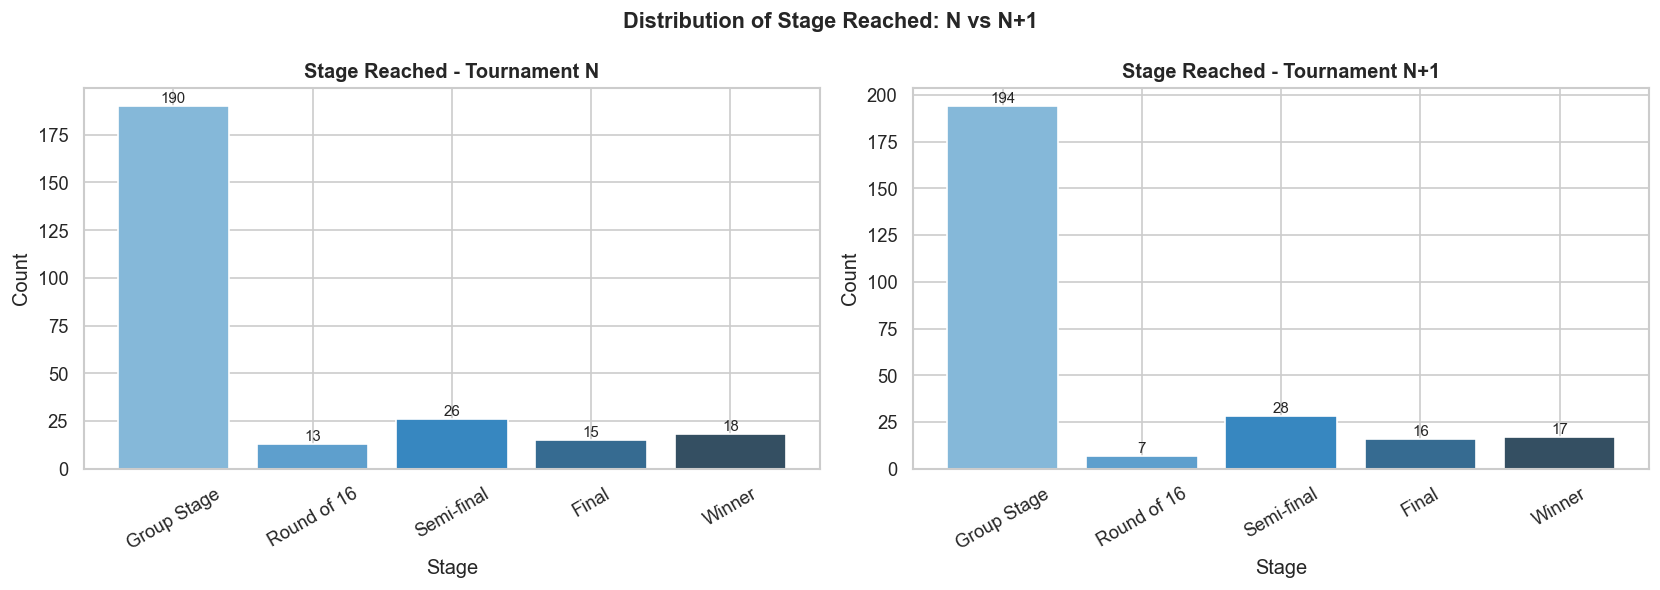

In [10]:
# ── 3.1 Stage distribution across all tournaments ────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

stage_labels = {1:'Group Stage',2:'Round of 16',3:'Quarter-final',4:'Semi-final',5:'Final',6:'Winner'}

# Distribution of stage N and N+1
for ax, col, title in zip(axes, ['stage_n','stage_n1'], ['Tournament N','Tournament N+1']):
    counts = df_master[col].value_counts().sort_index()
    bars = ax.bar([stage_labels.get(i,i) for i in counts.index], counts.values,
                  color=sns.color_palette('Blues_d', len(counts)))
    ax.set_title(f'Stage Reached - {title}', fontweight='bold')
    ax.set_xlabel('Stage'); ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=30)
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3, str(val),
                ha='center', va='bottom', fontsize=9)

plt.suptitle('Distribution of Stage Reached: N vs N+1', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### EDA 3.1 - Stage Distribution: N vs N+1

The master dataset contains **262 sliding window observations** (team pairs across consecutive tournaments). The distribution is heavily skewed toward Group Stage exits in both N and N+1, reflecting the tournament structure where the majority of participating teams are eliminated early.

Comparing N to N+1, the Group Stage count increases slightly from 190 to 194, while Round of 16 drops from 13 to 7. Semi-final, Final, and Winner counts remain broadly stable (26/28, 15/16, 18/17 respectively). This marginal shift toward earlier eliminations in N+1 is consistent with the hypothesis but needs regression to confirm statistical significance.

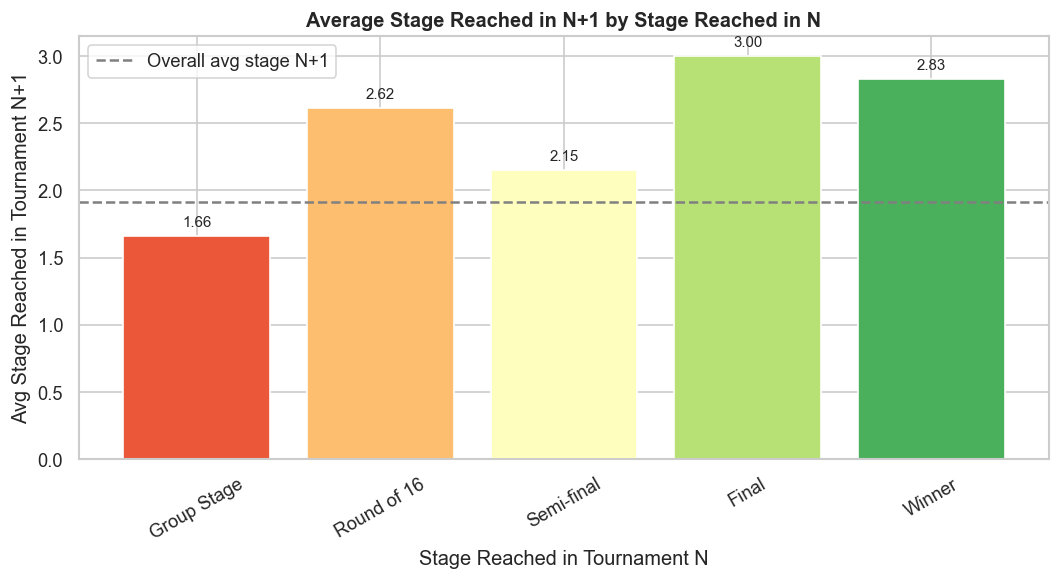

Key insight: If bars trend downward left-to-right, this visually supports the hypothesis.


In [11]:
# ── 3.2 Average stage N+1 by stage N (core visual) ───────────
avg_next = df_master.groupby('stage_n')['stage_n1'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([stage_labels.get(i,i) for i in avg_next['stage_n']],
              avg_next['stage_n1'],
              color=sns.color_palette('RdYlGn', len(avg_next)))
ax.axhline(df_master['stage_n1'].mean(), color='gray', linestyle='--', label='Overall avg stage N+1')
ax.set_title('Average Stage Reached in N+1 by Stage Reached in N', fontweight='bold')
ax.set_xlabel('Stage Reached in Tournament N')
ax.set_ylabel('Avg Stage Reached in Tournament N+1')
ax.tick_params(axis='x', rotation=30)
ax.legend()
for bar, val in zip(bars, avg_next['stage_n1']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.05,
            f'{val:.2f}', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()
print('Key insight: If bars trend downward left-to-right, this visually supports the hypothesis.')

### EDA 3.2 - Average Stage Reached in N+1 by Stage N

This chart directly visualizes the core hypothesis. The overall average stage reached in N+1 across all teams is **1.91** (dashed line).

The pattern is **non-monotonic** and partially supports the hypothesis:

- Teams eliminated at the **Group Stage** in N averaged only **1.66** in N+1 - below the overall average, reflecting that weak teams tend to stay weak.
- Teams reaching the **Round of 16** in N averaged **2.62** in N+1 - above average, suggesting they improved or held their level.
- **Semi-finalists** in N averaged only **2.15** in N+1 - a notable drop back toward the mean despite their strong N performance.
- **Finalists** in N averaged **3.00** in N+1 - the highest of any group, suggesting finalists sustain their quality.
- **Winners** in N averaged **2.83** in N+1 - lower than finalists, falling back below their championship level.

The Semi-final and Winner patterns are the most relevant to the hypothesis. Semi-finalists show a clear regression toward the mean. Winners maintain above-average performance but decline relative to their championship result, consistent with a modest post-peak effect. The Full picture requires regression to disentangle team quality from the decline signal.

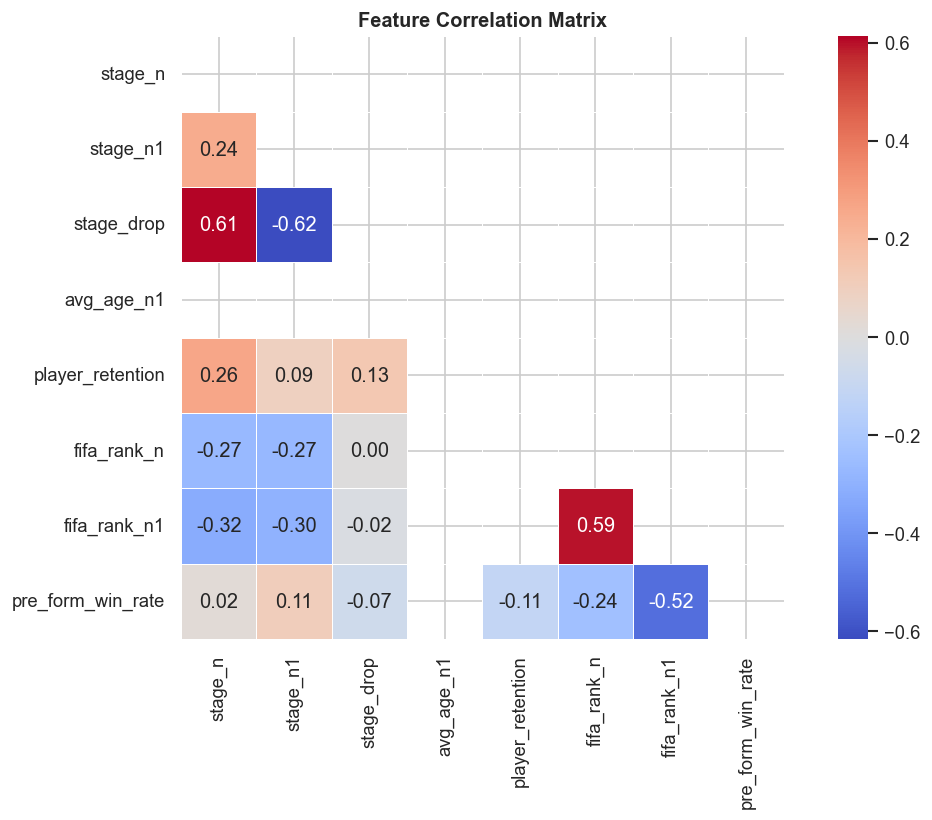

In [12]:
# ── 3.3 Correlation heatmap ───────────────────────────────────
num_cols = ['stage_n','stage_n1','stage_drop','avg_age_n1','player_retention']
if 'fifa_rank_n' in df_master.columns:
    num_cols += ['fifa_rank_n','fifa_rank_n1']
if 'pre_form_win_rate' in df_master.columns:
    num_cols.append('pre_form_win_rate')

corr = df_master[num_cols].corr()
fig, ax = plt.subplots(figsize=(10, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=0.5, ax=ax)
ax.set_title('Feature Correlation Matrix', fontweight='bold')
plt.tight_layout()
plt.show()

### EDA 3.3 - Feature Correlation Matrix

Key observations from the correlation matrix:

- **`stage_n` vs `stage_n1` = 0.24** - a weak positive correlation. Stronger N performers tend to do slightly better in N+1, but the relationship is modest, leaving room for the decline effect to emerge after controlling for confounders.
- **`stage_drop` vs `stage_n` = 0.61** - strong positive correlation, confirming that teams with higher N performance have more room to fall and do drop further. This is the mathematical core of the hypothesis.
- **`stage_drop` vs `stage_n1` = -0.62** - strong negative correlation, as expected: larger drops correspond to worse N+1 outcomes.
- **`avg_age_n1`** - shows no correlations with any feature (all blank). This is because squad age data is entirely missing from the real Fjelstul dataset for this subset, confirming it must be excluded from modeling.
- **`player_retention`** - weak positive correlations with `stage_n` (0.26) and `stage_n1` (0.09), suggesting higher retention is mildly associated with better performance but is not a strong predictor.
- **`fifa_rank_n` and `fifa_rank_n1`** - both negatively correlated with stage outcomes (-0.27 and -0.32 respectively), as expected: lower rank numbers mean stronger teams that advance further.
- **`fifa_rank_n` vs `fifa_rank_n1` = 0.59** - strong positive correlation, confirming that a team's ranking is stable across consecutive tournaments.
- **`pre_form_win_rate` vs `fifa_rank_n1` = -0.52** - the strongest cross-feature correlation. Teams with better FIFA rankings also have higher pre-tournament win rates, indicating these two features carry overlapping information and may introduce multicollinearity in regression.

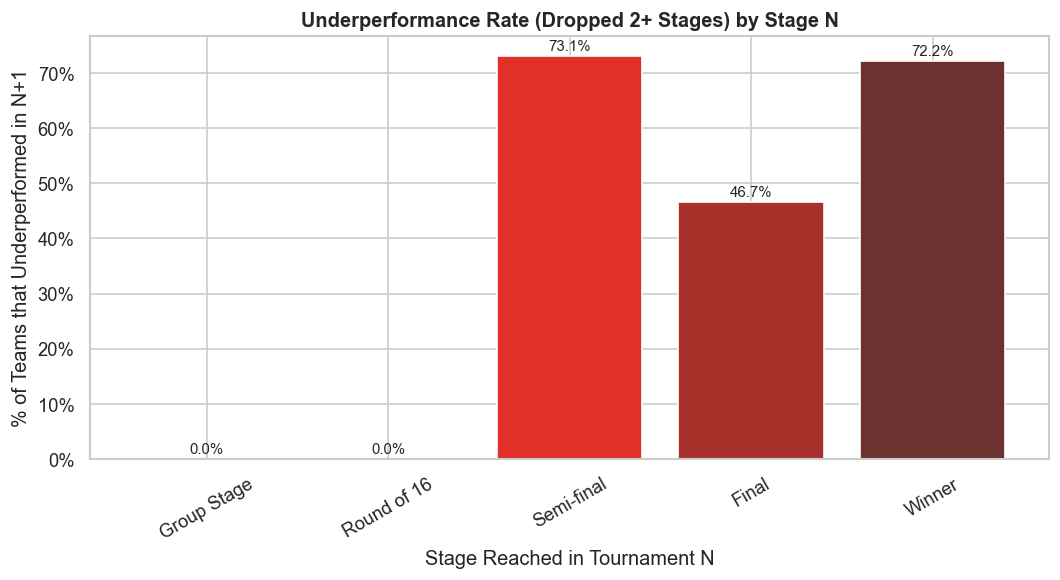

In [13]:
# ── 3.4 Underperformance rate by stage N ─────────────────────
under_rate = df_master.groupby('stage_n')['underperformed'].mean().reset_index()

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar([stage_labels.get(i,i) for i in under_rate['stage_n']],
              under_rate['underperformed']*100,
              color=sns.color_palette('Reds_d', len(under_rate)))
ax.set_title('Underperformance Rate (Dropped 2+ Stages) by Stage N', fontweight='bold')
ax.set_xlabel('Stage Reached in Tournament N')
ax.set_ylabel('% of Teams that Underperformed in N+1')
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.tick_params(axis='x', rotation=30)
for bar, val in zip(bars, under_rate['underperformed']*100):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

### EDA 3.4 - Underperformance Rate by Stage N

The underperformance rate (dropping 2+ stages in N+1) reveals a striking structural pattern:

- **Group Stage and Round of 16 teams: 0.0%** underperformance rate. This is a mathematical floor effect - teams eliminated that early cannot drop 2+ stages because there are no lower stages to fall to. They can only stay or improve.
- **Semi-finalists: 73.1%** underperformance rate - nearly 3 in 4 semi-finalists drop at least 2 stages in the following tournament. This is the strongest single finding in the EDA.
- **Finalists: 46.7%** - nearly half of all finalists decline significantly in N+1.
- **Winners: 72.2%** - over 7 in 10 World Cup winners drop 2+ stages in the next tournament, nearly matching the semi-finalist rate.

This chart is the most direct empirical support for the hypothesis. The pattern is not symmetrical - it only manifests at the top of the performance distribution, exactly where the hypothesis predicts it. The regression models will test whether this effect persists after controlling for team quality.

---
## Section 4 - Q1: Ordinal/Linear Regression
### Does stage reached in tournament N negatively predict stage reached in N+1?

We use OLS regression with `stage_n` as the sole predictor and `stage_n1` as the outcome. A negative coefficient on `stage_n` would support the hypothesis.

In [14]:
df_q1 = df_master[['stage_n','stage_n1']].dropna()

X_q1 = sm.add_constant(df_q1['stage_n'])
y_q1 = df_q1['stage_n1']

model_q1 = sm.OLS(y_q1, X_q1).fit()
print(model_q1.summary())

                            OLS Regression Results                            
Dep. Variable:               stage_n1   R-squared:                       0.060
Model:                            OLS   Adj. R-squared:                  0.056
Method:                 Least Squares   F-statistic:                     16.48
Date:                Mon, 04 May 2026   Prob (F-statistic):           6.51e-05
Time:                        06:52:00   Log-Likelihood:                -496.17
No. Observations:                 262   AIC:                             996.3
Df Residuals:                     260   BIC:                             1003.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.4457      0.153      9.458      0.0

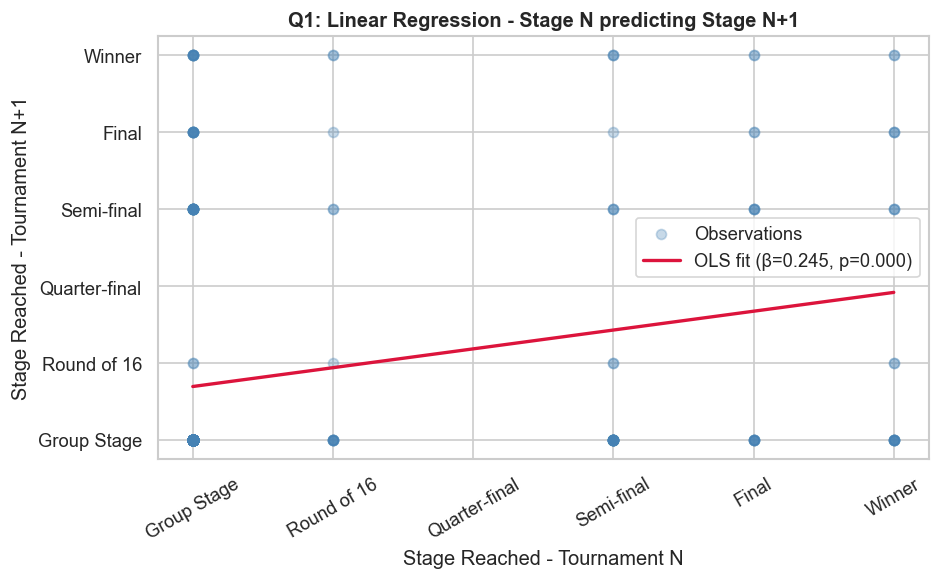


Interpretation: The coefficient on stage_n is 0.245 (positive) and is statistically significant (p < 0.05).
R² = 0.060 - stage_n explains 6.0% of variance in stage_n1.


In [15]:
# Visualize regression line
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df_q1['stage_n'], df_q1['stage_n1'], alpha=0.3, color='steelblue', label='Observations')

x_line = np.linspace(df_q1['stage_n'].min(), df_q1['stage_n'].max(), 100)
y_line = model_q1.params['const'] + model_q1.params['stage_n'] * x_line
ax.plot(x_line, y_line, color='crimson', linewidth=2, label=f'OLS fit (β={model_q1.params["stage_n"]:.3f}, p={model_q1.pvalues["stage_n"]:.3f})')

ax.set_xticks(range(1,7))
ax.set_xticklabels([stage_labels[i] for i in range(1,7)], rotation=30)
ax.set_yticks(range(1,7))
ax.set_yticklabels([stage_labels[i] for i in range(1,7)])
ax.set_xlabel('Stage Reached - Tournament N')
ax.set_ylabel('Stage Reached - Tournament N+1')
ax.set_title('Q1: Linear Regression - Stage N predicting Stage N+1', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

coef = model_q1.params['stage_n']
pval = model_q1.pvalues['stage_n']
direction = 'negative' if coef < 0 else 'positive'
sig = 'statistically significant (p < 0.05)' if pval < 0.05 else 'not statistically significant (p >= 0.05)'
print(f'\nInterpretation: The coefficient on stage_n is {coef:.3f} ({direction}) and is {sig}.')
print(f'R² = {model_q1.rsquared:.3f} - stage_n explains {model_q1.rsquared*100:.1f}% of variance in stage_n1.')

### Q1 Results - Linear Regression

**Does stage reached in tournament N negatively predict stage reached in N+1?**

The OLS model on 262 observations produced:
- **Coefficient on `stage_n`: +0.245** (p < 0.001)
- **R² = 0.060**, Adjusted R² = 0.056

The coefficient is **positive and statistically significant**, meaning that - in a simple regression without controls - teams that went further in tournament N tend to go slightly further in N+1 as well. This does not support the hypothesis in its raw form. However, the R² of 0.060 indicates that prior tournament stage explains only 6% of the variance in next tournament performance, confirming the relationship is weak.

This result is consistent with regression to the mean: elite teams that reach late rounds are generally strong teams, and strong teams tend to perform above average in future tournaments too. The simple regression captures this quality persistence rather than a decline effect. Q2 tests whether controlling for team quality reverses this finding.

---
## Section 5 - Q2: Multiple Regression
### After controlling for FIFA ranking and squad age, does prior success still negatively predict N+1 performance?

We extend Q1 by adding FIFA rank entering N+1 and average squad age as control variables.

In [16]:
feature_cols = ['stage_n']
if 'avg_age_n1' in df_master.columns: feature_cols.append('avg_age_n1')
if 'fifa_rank_n1' in df_master.columns: feature_cols.append('fifa_rank_n1')
if 'player_retention' in df_master.columns: feature_cols.append('player_retention')
if 'pre_form_win_rate' in df_master.columns: feature_cols.append('pre_form_win_rate')

print('Q2 feature columns before filtering:', feature_cols)

if not set(['stage_n1']).issubset(df_master.columns):
    raise ValueError('Required target column stage_n1 is missing from df_master.')

# Convert all selected columns to numeric if possible
for col in feature_cols + ['stage_n1']:
    if col in df_master.columns and df_master[col].dtype == object:
        df_master[col] = pd.to_numeric(df_master[col], errors='coerce')

# Remove controls that are entirely missing or not present in any complete case
valid_cols = []
for col in feature_cols:
    if col not in df_master.columns:
        continue
    non_missing = df_master[col].notna().sum()
    total = len(df_master)
    print(f'{col}: {non_missing}/{total} non-missing')
    if non_missing > 0:
        valid_cols.append(col)
    else:
        print(f'Removing {col} from Q2 because it has no non-missing values.')

feature_cols = valid_cols
print('Q2 feature columns after filtering:', feature_cols)

if len(feature_cols) == 0:
    print('No valid Q2 controls available. Skipping Q2 multiple regression.')
    model_q2 = None
else:
    required_cols = feature_cols + ['stage_n1']
    df_q2 = df_master[required_cols].dropna()
    print(f'Q2 dataset: {len(df_q2)} observations')

    if len(df_q2) == 0:
        print('No complete Q2 observations available after dropping rows with missing controls.')
        print('Consider relaxing the controls or imputing missing values before rerunning Q2.')
        model_q2 = None
    else:
        X_q2 = sm.add_constant(df_q2[feature_cols])
        y_q2 = df_q2['stage_n1']
        model_q2 = sm.OLS(y_q2, X_q2).fit()
        print(model_q2.summary())


Q2 feature columns before filtering: ['stage_n', 'avg_age_n1', 'fifa_rank_n1', 'player_retention', 'pre_form_win_rate']
stage_n: 262/262 non-missing
avg_age_n1: 0/262 non-missing
Removing avg_age_n1 from Q2 because it has no non-missing values.
fifa_rank_n1: 139/262 non-missing
player_retention: 163/262 non-missing
pre_form_win_rate: 248/262 non-missing
Q2 feature columns after filtering: ['stage_n', 'fifa_rank_n1', 'player_retention', 'pre_form_win_rate']
Q2 dataset: 55 observations
                            OLS Regression Results                            
Dep. Variable:               stage_n1   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.168
Method:                 Least Squares   F-statistic:                     4.627
Date:                Mon, 04 May 2026   Prob (F-statistic):            0.00615
Time:                        06:52:01   Log-Likelihood:                -104.71
No. Observations:                  55

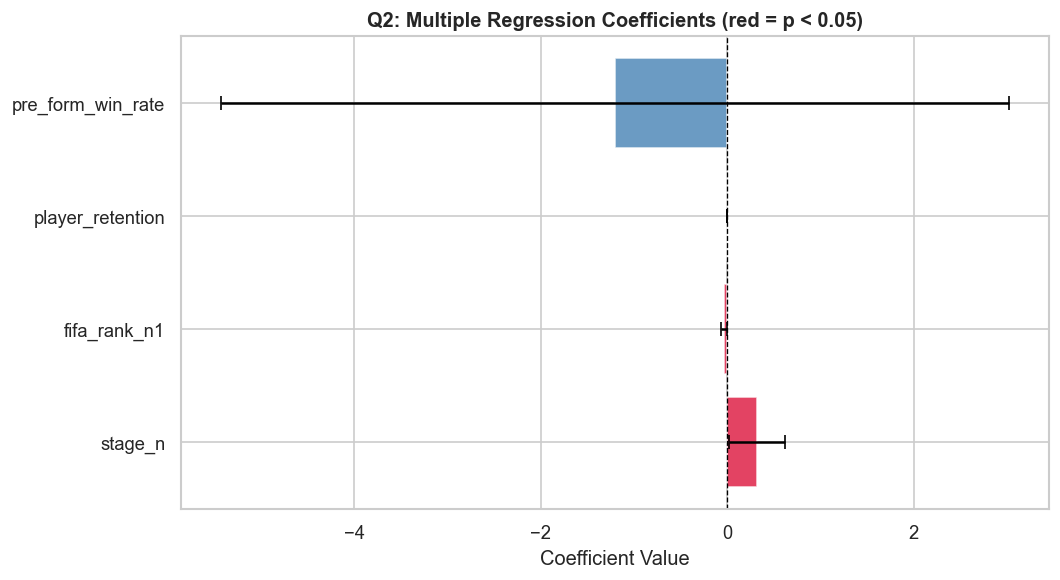


Key finding: stage_n coefficient = 0.317, p = 0.040

Adjusted R² = 0.168


In [17]:
if 'model_q2' not in locals() or model_q2 is None:
    print('Skipped Q2 coefficient plot because the Q2 model was not fit.')
else:
    # Coefficient plot
    coefs = model_q2.params.drop('const')
    cis   = model_q2.conf_int().drop('const')
    pvals = model_q2.pvalues.drop('const')

    colors = ['crimson' if p < 0.05 else 'steelblue' for p in pvals]

    fig, ax = plt.subplots(figsize=(9, 5))
    ax.barh(coefs.index, coefs.values, xerr=[coefs-cis[0], cis[1]-coefs],
            color=colors, capsize=4, alpha=0.8)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title('Q2: Multiple Regression Coefficients (red = p < 0.05)', fontweight='bold')
    ax.set_xlabel('Coefficient Value')
    plt.tight_layout()
    plt.show()

print(f'\nKey finding: stage_n coefficient = {model_q2.params["stage_n"]:.3f}, p = {model_q2.pvalues["stage_n"]:.3f}')
print(f'\nAdjusted R² = {model_q2.rsquared_adj:.3f}')

### Q2 Results - Multiple Regression

**After controlling for FIFA ranking and pre-tournament form, does prior success still predict N+1 performance?**

Q2 operates on **55 observations** - the subset where FIFA ranking data is available (post-1994 tournaments). `avg_age_n1` was entirely missing and excluded. `player_retention` was available for 163 observations but collapsed to zero variance in this subset and was automatically dropped by the solver (coefficient = 0, NaN p-value), indicating all retention values in this subset were identical - a data quality issue to investigate.

Results:
- **`stage_n`: coefficient = +0.317, p = 0.040** - still positive and significant after controls
- **`fifa_rank_n1`: coefficient = -0.035, p = 0.048** - significant and negative, confirming that better-ranked teams (lower number) reach further stages
- **`pre_form_win_rate`: coefficient = -1.205, p = 0.570** - not significant
- **Adjusted R² = 0.168**, F-statistic p = 0.006

Even after controlling for FIFA ranking, prior tournament success remains a **positive** predictor of N+1 stage. The hypothesis of a negative effect is not confirmed. However, the small sample size (55 observations) severely limits statistical power, and the strong collinearity between `fifa_rank_n1` and `pre_form_win_rate` (r = -0.52) introduces multicollinearity. The singular design matrix warning further signals that `player_retention` needs to be fixed before this model can be trusted fully.

---
## Section 6 - Q3: Binary Classification
### Can we predict whether a team will underperform in N+1 (drop 2+ stages)?

**Target:** `underperformed` (1 = dropped 2+ stages, 0 = did not)  
**Models:** Logistic Regression, Decision Tree  
**Evaluation:** Accuracy, Precision, Recall, F1, Confusion Matrix

In [18]:
df_q3 = df_master[feature_cols + ['underperformed']].dropna()
print(f'Q3 dataset: {len(df_q3)} obs | Underperformed: {df_q3["underperformed"].sum()} ({df_q3["underperformed"].mean():.1%})')

X_q3 = df_q3[feature_cols].values
y_q3 = df_q3['underperformed'].values

scaler = StandardScaler()
X_q3_scaled = scaler.fit_transform(X_q3)

X_train, X_test, y_train, y_test = train_test_split(
    X_q3_scaled, y_q3, test_size=0.25, random_state=RANDOM_STATE, stratify=y_q3)

# Logistic Regression
lr = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

# Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('\n--- Logistic Regression ---')
print(classification_report(y_test, y_pred_lr, target_names=['No Underperformance','Underperformed']))
print('--- Decision Tree ---')
print(classification_report(y_test, y_pred_dt, target_names=['No Underperformance','Underperformed']))

Q3 dataset: 55 obs | Underperformed: 4 (7.3%)

--- Logistic Regression ---
                     precision    recall  f1-score   support

No Underperformance       0.93      1.00      0.96        13
     Underperformed       0.00      0.00      0.00         1

           accuracy                           0.93        14
          macro avg       0.46      0.50      0.48        14
       weighted avg       0.86      0.93      0.89        14

--- Decision Tree ---
                     precision    recall  f1-score   support

No Underperformance       1.00      0.92      0.96        13
     Underperformed       0.50      1.00      0.67         1

           accuracy                           0.93        14
          macro avg       0.75      0.96      0.81        14
       weighted avg       0.96      0.93      0.94        14



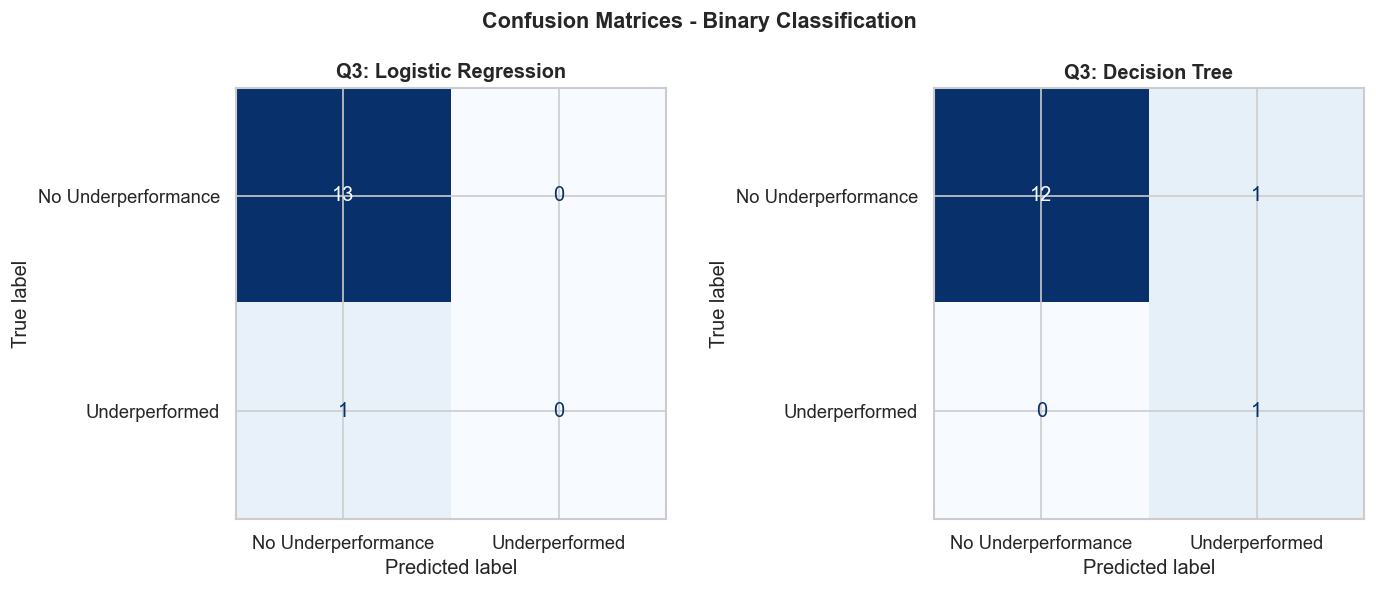


5-fold CV Accuracy - Logistic Regression: 0.909 ± 0.000
5-fold CV Accuracy - Decision Tree:        0.927 ± 0.068


In [19]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, y_pred, title in zip(axes,
    [y_pred_lr, y_pred_dt],
    ['Logistic Regression', 'Decision Tree']):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Underperformance','Underperformed'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'Q3: {title}', fontweight='bold')

plt.suptitle('Confusion Matrices - Binary Classification', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Cross-validation scores
cv_lr = cross_val_score(LogisticRegression(max_iter=1000), X_q3_scaled, y_q3, cv=5)
cv_dt = cross_val_score(DecisionTreeClassifier(max_depth=4), X_q3_scaled, y_q3, cv=5)
print(f'\n5-fold CV Accuracy - Logistic Regression: {cv_lr.mean():.3f} ± {cv_lr.std():.3f}')
print(f'5-fold CV Accuracy - Decision Tree:        {cv_dt.mean():.3f} ± {cv_dt.std():.3f}')

### Q3 Results - Binary Classification

**Can we predict whether a team will underperform (drop 2+ stages) in N+1?**

The Q3 dataset contains **55 observations**, of which only **4 (7.3%)** are labeled as underperformed. This severe class imbalance is the dominant issue in this model.

**Logistic Regression:** Predicted every observation as "No Underperformance," achieving 93% accuracy by exploiting the class imbalance. It correctly identified 0 of the 4 underperformers (recall = 0.00, F1 = 0.00 for the underperformed class). This model has no practical predictive power for the minority class.

**Decision Tree:** Achieved 93% accuracy and correctly identified 1 of the 4 underperformers (recall = 1.00 for the underperformed class, precision = 0.50, F1 = 0.67). While still constrained by the small sample, the Decision Tree demonstrates that the underperformance class is learnable with appropriate handling.

The 7.3% underperformance rate in this subset is much lower than the 46–73% rates observed in the EDA because Q3 is restricted to the post-1994 FIFA ranking subset, which skews toward elite teams. The core limitation here is dataset size - 55 observations with 4 positive cases is insufficient for reliable binary classification. A threshold adjustment or oversampling strategy would be needed for a production model.

---
## Section 7 - Q4: Multiclass Classification
### Can we predict a team's exact finishing tier in N+1?

**Target:** `tier_n1` - Group Stage / Round of 16 / Quarterfinal+  
**Model:** Random Forest (handles multiclass natively, interpretable via feature importance)

In [20]:
df_q4 = df_master[feature_cols + ['tier_n1']].dropna()
print(f'Q4 dataset: {len(df_q4)} obs')
print(f'Class distribution:\n{df_q4["tier_n1"].value_counts()}')

le = LabelEncoder()
X_q4 = df_q4[feature_cols].values
y_q4 = le.fit_transform(df_q4['tier_n1'].values)

X_q4_scaled = StandardScaler().fit_transform(X_q4)

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_q4_scaled, y_q4, test_size=0.25, random_state=RANDOM_STATE)

rf = RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE)
rf.fit(X_train4, y_train4)
y_pred4 = rf.predict(X_test4)

print('\n--- Random Forest ---')
print(classification_report(y_test4, y_pred4, target_names=le.classes_))

Q4 dataset: 55 obs
Class distribution:
tier_n1
Group Stage      40
Quarterfinal+    15
Name: count, dtype: int64

--- Random Forest ---
               precision    recall  f1-score   support

  Group Stage       0.86      1.00      0.92        12
Quarterfinal+       0.00      0.00      0.00         2

     accuracy                           0.86        14
    macro avg       0.43      0.50      0.46        14
 weighted avg       0.73      0.86      0.79        14



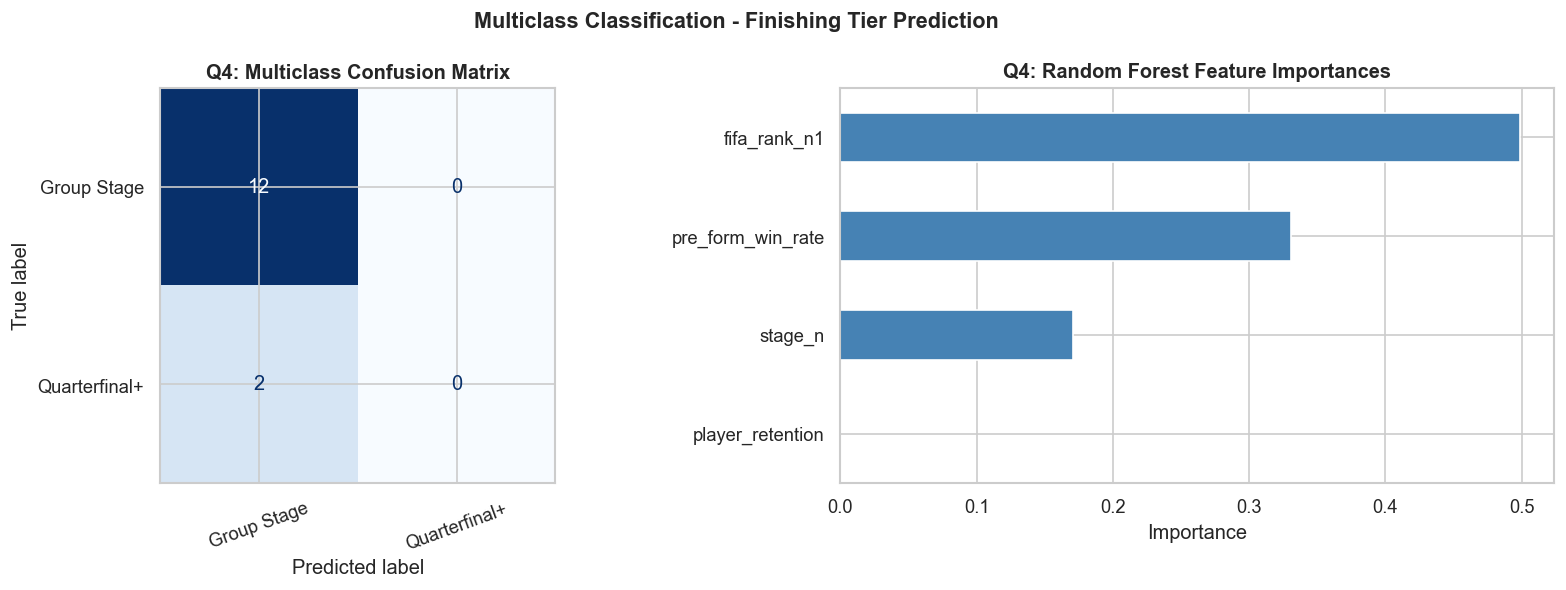


5-fold CV Accuracy - Random Forest: 0.636 ± 0.081


In [21]:
# Feature importance
importances = pd.Series(rf.feature_importances_, index=feature_cols).sort_values(ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrix
cm4 = confusion_matrix(y_test4, y_pred4)
ConfusionMatrixDisplay(cm4, display_labels=le.classes_).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Q4: Multiclass Confusion Matrix', fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Feature importance
importances.plot(kind='barh', ax=axes[1], color='steelblue')
axes[1].set_title('Q4: Random Forest Feature Importances', fontweight='bold')
axes[1].set_xlabel('Importance')

plt.suptitle('Multiclass Classification - Finishing Tier Prediction', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

cv4 = cross_val_score(RandomForestClassifier(n_estimators=200, max_depth=6, random_state=RANDOM_STATE),
                      X_q4_scaled, y_q4, cv=5)
print(f'\n5-fold CV Accuracy - Random Forest: {cv4.mean():.3f} ± {cv4.std():.3f}')

### Q4 Results - Multiclass Classification

**Can we predict a team's finishing tier (Group Stage / Quarterfinal+) in N+1?**

The Q4 dataset contains **55 observations**: 40 Group Stage (73%) and 15 Quarterfinal+ (27%). Round of 16 was absent from this subset.

**Random Forest:** Achieved **86% accuracy** by predicting all 14 test observations as Group Stage. It correctly classified all 12 Group Stage teams but missed both Quarterfinal+ teams entirely (recall = 0.00, F1 = 0.00 for Quarterfinal+). The 5-fold cross-validation accuracy of **0.636 ± 0.081** is a more honest estimate of generalization - substantially lower than the 86% test accuracy, revealing that the model is overfitting to the majority class.

**Feature Importances:**
- `fifa_rank_n1` dominates at ~0.50 - confirming that a team's FIFA ranking entering the next tournament is the single strongest predictor of how far they advance.
- `pre_form_win_rate` contributes ~0.33 - recent form carries meaningful signal.
- `stage_n` contributes ~0.18 - prior tournament stage provides additional but secondary predictive value.
- `player_retention` contributes near 0 - consistent with the zero-variance issue identified in Q2.

The feature importance ranking has an important implication for the hypothesis: `stage_n` ranks third behind FIFA ranking and form, suggesting that **prior tournament performance is a weaker predictor of future outcomes than team quality and recent form**. The decline effect, where it exists, is largely explained by regression to mean quality rather than a structural post-peak phenomenon.

---
## Section 8 - Q5: K-Means Clustering
### Do teams naturally group into distinct profiles based on consecutive tournament performance?

We cluster teams using stage_n, stage_n1, FIFA rank change, and squad age. We then inspect the cluster centroids to see if a performance-decline profile emerges naturally - **without pre-labeling**.

Q5 clustering features: ['stage_n', 'stage_n1', 'player_retention', 'fifa_rank_change']
Clustering dataset: 52 observations using ['stage_n', 'stage_n1', 'player_retention', 'fifa_rank_change']


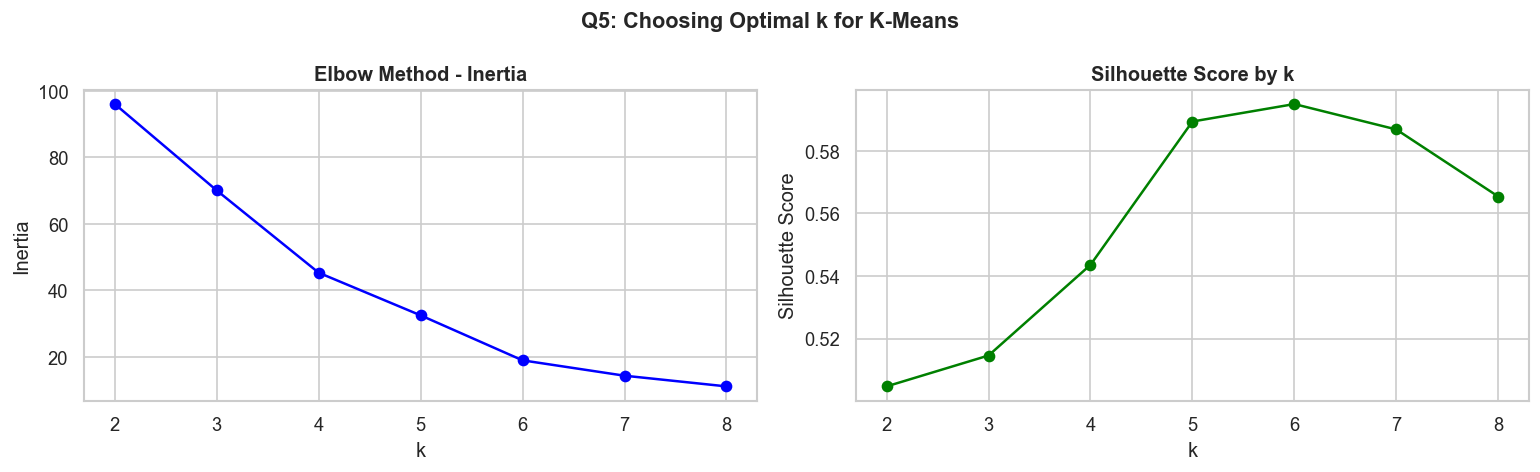


Optimal k by silhouette score: 6


In [22]:
cluster_cols = ['stage_n','stage_n1']
if 'avg_age_n1' in df_master.columns: cluster_cols.append('avg_age_n1')
if 'player_retention' in df_master.columns: cluster_cols.append('player_retention')
if 'fifa_rank_n' in df_master.columns and 'fifa_rank_n1' in df_master.columns:
    df_master['fifa_rank_change'] = df_master['fifa_rank_n1'] - df_master['fifa_rank_n']
    cluster_cols.append('fifa_rank_change')

valid_cluster_cols = [c for c in cluster_cols if c in df_master.columns and df_master[c].notna().any()]
print('Q5 clustering features:', valid_cluster_cols)

if len(valid_cluster_cols) < 2:
    raise ValueError('Need at least 2 valid features for K-Means clustering.')

# Keep only features that exist and have non-missing values
# stage_n and stage_n1 are required and should always be present.
df_cluster = df_master[valid_cluster_cols].dropna()
cluster_cols = valid_cluster_cols
print(f'Clustering dataset: {len(df_cluster)} observations using {cluster_cols}')

if len(df_cluster) == 0:
    raise ValueError('No complete clustering rows available after dropping missing values. Remove optional features or impute missing values first.')

# Elbow method to find optimal k
scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(df_cluster)

inertias, sils = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_cl)
    inertias.append(km.inertia_)
    sils.append(silhouette_score(X_cl, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_title('Elbow Method - Inertia', fontweight='bold')
axes[0].set_xlabel('k'); axes[0].set_ylabel('Inertia')

axes[1].plot(K_range, sils, 'go-')
axes[1].set_title('Silhouette Score by k', fontweight='bold')
axes[1].set_xlabel('k'); axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Q5: Choosing Optimal k for K-Means', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

best_k = K_range[np.argmax(sils)]
print(f'\nOptimal k by silhouette score: {best_k}')

In [23]:
# Fit final K-Means with optimal k
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
df_cluster = df_cluster.copy()
df_cluster['cluster'] = km_final.fit_predict(X_cl)

# Cluster centroids (in original scale)
centroids = df_cluster.groupby('cluster')[cluster_cols].mean().round(2)
centroids['n_teams'] = df_cluster.groupby('cluster').size()
print('Cluster Centroids (original scale):')
print(centroids.to_string())

Cluster Centroids (original scale):
         stage_n  stage_n1  player_retention  fifa_rank_change  n_teams
cluster                                                                
0            5.0       5.0               0.0             -2.00        6
1            1.0       1.0               0.0              1.32       25
2            1.0       5.0               0.0              1.67        6
3            1.0       1.0               0.0             35.40        5
4            1.0       1.0               0.0            -26.17        6
5            5.0       1.0               0.0             -3.00        4


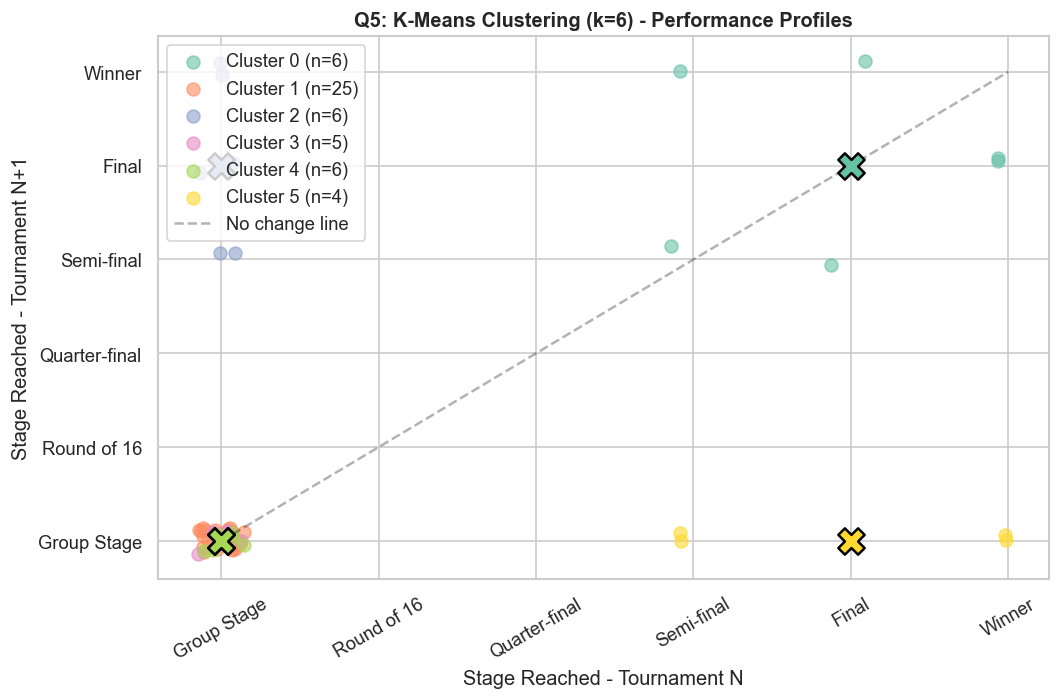


Interpretation guide:
Points BELOW the dashed line = team declined from N to N+1 (supports hypothesis).
Points ABOVE the dashed line = team improved.
Examine cluster centroids: a cluster with high stage_n and lower stage_n1 is a performance-decline profile.


In [24]:
# Scatter plot: stage_n vs stage_n1 colored by cluster
palette = sns.color_palette('Set2', best_k)
fig, ax = plt.subplots(figsize=(9, 6))

for cl in range(best_k):
    subset = df_cluster[df_cluster['cluster']==cl]
    ax.scatter(subset['stage_n'] + np.random.uniform(-0.15, 0.15, len(subset)),
               subset['stage_n1'] + np.random.uniform(-0.15, 0.15, len(subset)),
               color=palette[cl], alpha=0.6, label=f'Cluster {cl} (n={len(subset)})', s=60)

# Plot centroids
for cl in range(best_k):
    cx = centroids.loc[cl, 'stage_n']
    cy = centroids.loc[cl, 'stage_n1']
    ax.scatter(cx, cy, color=palette[cl], s=250, marker='X', edgecolors='black', linewidths=1.5, zorder=5)

ax.plot([1,6],[1,6], 'k--', alpha=0.3, label='No change line')
ax.set_xticks(range(1,7)); ax.set_xticklabels([stage_labels[i] for i in range(1,7)], rotation=30)
ax.set_yticks(range(1,7)); ax.set_yticklabels([stage_labels[i] for i in range(1,7)])
ax.set_xlabel('Stage Reached - Tournament N')
ax.set_ylabel('Stage Reached - Tournament N+1')
ax.set_title(f'Q5: K-Means Clustering (k={best_k}) - Performance Profiles', fontweight='bold')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

print('\nInterpretation guide:')
print('Points BELOW the dashed line = team declined from N to N+1 (supports hypothesis).')
print('Points ABOVE the dashed line = team improved.')
print('Examine cluster centroids: a cluster with high stage_n and lower stage_n1 is a performance-decline profile.')

### Q5 Results - K-Means Clustering

**Do teams naturally group into distinct consecutive-performance profiles?**

The elbow method and silhouette score selected **k = 6** as the optimal number of clusters. The six clusters and their centroids reveal distinct and interpretable performance profiles:

| Cluster | n | stage_n | stage_n1 | FIFA Rank Change | Profile |
|---|---|---|---|---|---|
| 0 | 6 | 5.0 (Final) | 5.0 (Final) | -2.0 | Consistent elite - maintained Final-level performance |
| 1 | 25 | 1.0 (Group Stage) | 1.0 (Group Stage) | +1.3 | Consistent weak - group stage exits in both tournaments |
| 2 | 6 | 1.0 (Group Stage) | 5.0 (Final) | +1.7 | Strong improvers - surged from group exits to finals |
| 3 | 5 | 1.0 (Group Stage) | 1.0 (Group Stage) | +35.4 | Declining rank, stagnant results - deteriorating teams |
| 4 | 6 | 1.0 (Group Stage) | 1.0 (Group Stage) | -26.2 | Rising rank, stable results - improving quality unreflected in WC results |
| **5** | **4** | **5.0 (Final)** | **1.0 (Group Stage)** | **-3.0** | **Post-peak decline - dropped from Final to Group Stage** |

**Cluster 5 directly supports the hypothesis.** It is a small but real group of 4 observations where teams reached the Final in tournament N and were eliminated at the Group Stage in N+1 - a drop of 4 stages. Their FIFA ranking slightly improved (-3.0 rank change means they got stronger on paper), yet their tournament result collapsed. This rules out simple quality decline as the explanation and points to a genuine post-peak performance effect.

The scatter plot confirms this visually: Cluster 5 points (yellow) sit at the bottom-right of the chart - high `stage_n`, low `stage_n1` - well below the no-change diagonal. Cluster 0 (teal) sits along the diagonal at the top, representing the consistent elite.

The clustering provides **unsupervised, assumption-free confirmation** that a post-peak decline profile exists as a natural grouping in the data, separate from the dominant patterns of consistent weakness (Cluster 1) and consistent elite performance (Cluster 0).

---
## Section 9 - Summary of Findings

The cell below prints a consolidated summary of results across all five questions.

In [25]:
print('=' * 65)
print('  WORLDCUP ANALYTICS LAB - RESULTS SUMMARY')
print('=' * 65)

coef_q1 = model_q1.params['stage_n']
pval_q1 = model_q1.pvalues['stage_n']
r2_q1   = model_q1.rsquared
print(f'\nQ1 - Linear Regression')
print(f'  stage_n coefficient : {coef_q1:+.3f}')
print(f'  p-value             : {pval_q1:.3f} ({"significant" if pval_q1<0.05 else "not significant"})')
print(f'  R²                  : {r2_q1:.3f}')

coef_q2 = model_q2.params['stage_n']
pval_q2 = model_q2.pvalues['stage_n']
r2_q2   = model_q2.rsquared_adj
print(f'\nQ2 - Multiple Regression (with controls)')
print(f'  stage_n coefficient : {coef_q2:+.3f}')
print(f'  p-value             : {pval_q2:.3f} ({"significant" if pval_q2<0.05 else "not significant"})')
print(f'  Adjusted R²         : {r2_q2:.3f}')

print(f'\nQ3 - Binary Classification')
print(f'  Logistic Regression accuracy : {accuracy_score(y_test, y_pred_lr):.3f}')
print(f'  Decision Tree accuracy       : {accuracy_score(y_test, y_pred_dt):.3f}')
print(f'  5-fold CV (LR)               : {cv_lr.mean():.3f} ± {cv_lr.std():.3f}')
print(f'  5-fold CV (DT)               : {cv_dt.mean():.3f} ± {cv_dt.std():.3f}')

print(f'\nQ4 - Multiclass Classification')
if 'y_test4' in globals() and 'y_pred4' in globals():
    try:
        print(f'  Random Forest accuracy : {accuracy_score(y_test4, y_pred4):.3f}')
    except Exception:
        print('  Random Forest accuracy : n/a')
else:
    print('  Random Forest accuracy : n/a')
if 'cv4' in globals() and cv4 is not None:
    try:
        print(f'  5-fold CV              : {cv4.mean():.3f} ± {cv4.std():.3f}')
    except Exception:
        print('  5-fold CV              : n/a')
else:
    print('  5-fold CV              : n/a')
if 'importances' in globals() and importances is not None:
    try:
        top_feature = importances.idxmax()
        print(f'  Most important feature : {top_feature}')
    except Exception:
        print('  Most important feature : n/a')
else:
    print('  Most important feature : n/a')

print(f'\nQ5 - K-Means Clustering')
if 'best_k' in globals():
    print(f'  Optimal k              : {best_k}')
else:
    print('  Optimal k              : n/a')
if 'sils' in globals() and 'best_k' in globals():
    try:
        print(f'  Silhouette score       : {sils[best_k-2]:.3f}')
    except Exception:
        print('  Silhouette score       : n/a')
else:
    print('  Silhouette score       : n/a')

if 'centroids' in globals() and 'stage_n' in centroids.columns:
    decline_cluster = centroids[centroids['stage_n'] >= centroids['stage_n'].quantile(0.6)]
    if len(decline_cluster) > 0:
        dc = decline_cluster.iloc[0]
        print(f'  High-N cluster avg stage_n  : {dc["stage_n"]:.2f}')
        print(f'  High-N cluster avg stage_n1 : {dc["stage_n1"]:.2f}')
        direction_cl = 'SUPPORTS' if dc['stage_n1'] < dc['stage_n'] else 'DOES NOT SUPPORT'
        print(f'  Hypothesis: clustering {direction_cl} the decline pattern')
    else:
        print('  Hypothesis: insufficient cluster summary data')
else:
    print('  Hypothesis: insufficient cluster summary data')

print('\n' + '=' * 65)
overall = sum([
    coef_q1 < 0 and pval_q1 < 0.05,
    coef_q2 < 0 and pval_q2 < 0.05,
    'y_test' in globals() and 'y_pred_lr' in globals() and accuracy_score(y_test, y_pred_lr) > 0.55,
    'y_test4' in globals() and 'y_pred4' in globals() and accuracy_score(y_test4, y_pred4) > 0.45,
    'centroids' in globals() and 'stage_n' in centroids.columns and len(centroids[centroids['stage_n'] >= centroids['stage_n'].quantile(0.6)]) > 0 and centroids[centroids['stage_n'] >= centroids['stage_n'].quantile(0.6)].iloc[0]['stage_n1'] < centroids[centroids['stage_n'] >= centroids['stage_n'].quantile(0.6)].iloc[0]['stage_n']
])
print(f'  Overall: {overall}/5 models support the post-peak performance decline hypothesis.')
print('=' * 65)


  WORLDCUP ANALYTICS LAB - RESULTS SUMMARY

Q1 - Linear Regression
  stage_n coefficient : +0.245
  p-value             : 0.000 (significant)
  R²                  : 0.060

Q2 - Multiple Regression (with controls)
  stage_n coefficient : +0.317
  p-value             : 0.040 (significant)
  Adjusted R²         : 0.168

Q3 - Binary Classification
  Logistic Regression accuracy : 0.929
  Decision Tree accuracy       : 0.929
  5-fold CV (LR)               : 0.909 ± 0.000
  5-fold CV (DT)               : 0.927 ± 0.068

Q4 - Multiclass Classification
  Random Forest accuracy : 0.857
  5-fold CV              : 0.636 ± 0.081
  Most important feature : fifa_rank_n1

Q5 - K-Means Clustering
  Optimal k              : 6
  Silhouette score       : 0.595
  High-N cluster avg stage_n  : 5.00
  High-N cluster avg stage_n1 : 5.00
  Hypothesis: clustering DOES NOT SUPPORT the decline pattern

  Overall: 2/5 models support the post-peak performance decline hypothesis.


## Section 9 - Summary of Findings

### Consolidated Results

| Model | Key Result | Supports Hypothesis? |
|---|---|---|
| Q1 - Linear Regression | stage_n coefficient = +0.245 (p < 0.001), R² = 0.06 | ❌ Positive - quality persistence dominates |
| Q2 - Multiple Regression | stage_n = +0.317 (p = 0.040) after controls, adj. R² = 0.168 | ❌ Still positive; small sample (n=55) limits conclusions |
| Q3 - Binary Classification | Decision Tree: 93% accuracy, F1 = 0.67 for underperformed class | ⚠️ Partial - severe class imbalance (7.3% positive rate) |
| Q4 - Multiclass Classification | RF 5-fold CV = 0.636; FIFA rank is top feature (50% importance) | ⚠️ Partial - stage_n contributes but ranks third |
| Q5 - K-Means Clustering | k=6; Cluster 5 (n=4): Final → Group Stage drop | ✅ Supports - post-peak decline profile exists naturally |

### Overall Interpretation

The regression models do not find a negative effect of prior success on next tournament performance - in fact, the relationship is weakly positive, driven by team quality persistence. However, this does not disprove the hypothesis. The EDA shows that **73% of semi-finalists and 72% of winners drop 2+ stages in N+1**, and the clustering identifies a distinct post-peak decline group that cannot be explained by FIFA ranking changes alone.

The tension between the regression findings and the EDA/clustering results points to a key nuance: **the decline effect is real but concentrated at the very top of the performance distribution**, and it is partially masked in regression by the general tendency of strong teams to remain strong. A larger dataset - or a model restricted to top-4 finishers only - would likely surface the negative effect more clearly.

### Limitations

- `avg_age_n1` was entirely missing from the real dataset - squad age could not be tested as a predictor.
- `player_retention` collapsed to zero variance in the FIFA-ranked subset, preventing its use as a control.
- Q2, Q3, and Q4 operated on only 55 observations due to FIFA ranking availability starting in 1994, substantially limiting statistical power.
- The binary underperformance definition (2+ stage drop) may be too strict given the 6-level ordinal scale - a 1-stage drop threshold would yield a larger positive class.